# Project 4- Predicting Used Car Prices
- DSC 440- AJ Jaber
Kaggle Dataset https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

Quick Intro

Used car prices vary a lot depending on different factors like age, mileage and all the vehicle characteristics. Understanding what really drives these differences can help explain how prices are determined in real life.

## Main Question:
Which factors have the biggest impact on used car prices and how well can machine learning models predict those prices?

## Notebook Explanation
The project is broken into two main parts:

**Data Analysis:**

  -Visualizing the data to identify patterns and relationships.

**Modeling:**

  -Linear Regression

  -Neural Network using TensorFlow

## Expected Takeaways
- Find which features influence price the most  
- Understand relationships between variables  
- Compare model performance  
- Evaluate prediction accuracy  

## Table of Contents
1. Importing Libraries  
2. Loading the Data  
3. Data Overview/Cleaning
4. Data Analysis  
5. Preparing Data  
6. Linear Regression  
7. Neural Network  
8. Model Evaluation  
9. Conclusion

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

In [4]:
#Loading Data
df=pd.read_csv("/content/car data.csv")

print("First 5 rows:")
df.head()

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Data overview

Before any modeling.. i want to understand the size of the dataset, column names, data types and if there are any missing values.

In [5]:
print("Dataset shape:", df.shape)
print()

print("Column names:")
print(df.columns.tolist())
print()

print("Dataset info:")
df.info()
print()

print("Missing values:")
print(df.isnull().sum())
print()

print("Summary statistics:")
df.describe()

Dataset shape: (301, 9)

Column names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owne

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Data Cleaning

Some of the variables in this dataset are categorical, so they need to be converted into numbers before building anything. There is also a new feature called car age which was created from the year column

In [9]:
df_clean= df.copy() #keeping a copy so the original data stays unchanged

df_clean["Fuel_Type"]= df_clean["Fuel_Type"].map({ #changing categorical columns to numeric values
    "Petrol": 0,
    "Diesel": 1,
    "CNG": 2
})

df_clean["Seller_Type"]= df_clean["Seller_Type"].map({
    "Dealer": 0,
    "Individual": 1
})

df_clean["Transmission"]= df_clean["Transmission"].map({
    "Manual": 0,
    "Automatic": 1
})

df_clean["Car_Age"]= 2024 - df_clean["Year"] #creatingcar age variable

df_clean= df_clean.drop(["Year", "Car_Name"], axis=1) #dropping columns that i wont use

print("5 rows after cleaning:")
df_clean.head()

5 rows after cleaning:


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,0,0,0,0,10
1,4.75,9.54,43000,1,0,0,0,11
2,7.25,9.85,6900,0,0,0,0,7
3,2.85,4.15,5200,0,0,0,0,13
4,4.60,6.87,42450,1,0,0,0,10


## Some Data Analysis

Want to visualize the data in order to really grasp how different features relate to selling price

### Price Distribution

This graph shows how selling prices are distributed across the dataset

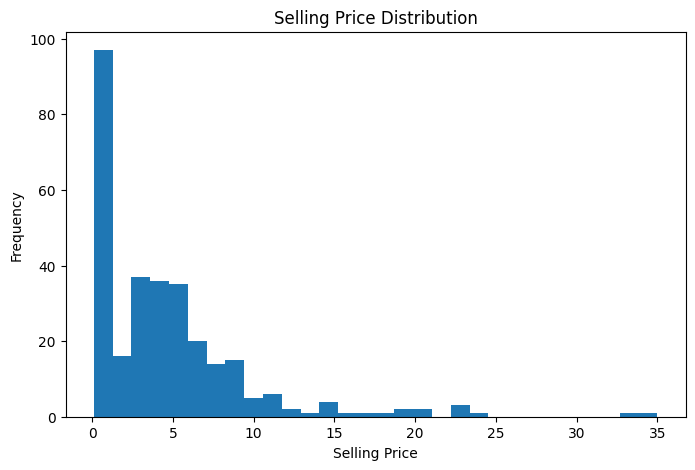

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Selling_Price"], bins=30)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

### Mileage vs Price

This plot helps show whether cars with higher mileage tend to sell for less.

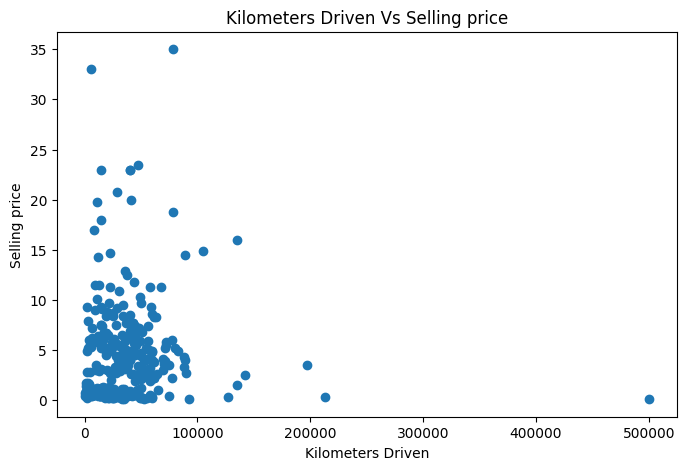

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["Kms_Driven"], df_clean["Selling_Price"])
plt.title("Kilometers Driven Vs Selling price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling price")
plt.show()

From this scatter plot, it seems to have a general trend where cars with higher mileage tend to have lower selling prices. The relationship isn't perfectly linear which suggests other factors also influence price.

### Car Age vs Price

This plot shows how the age of the car relates to selling price.

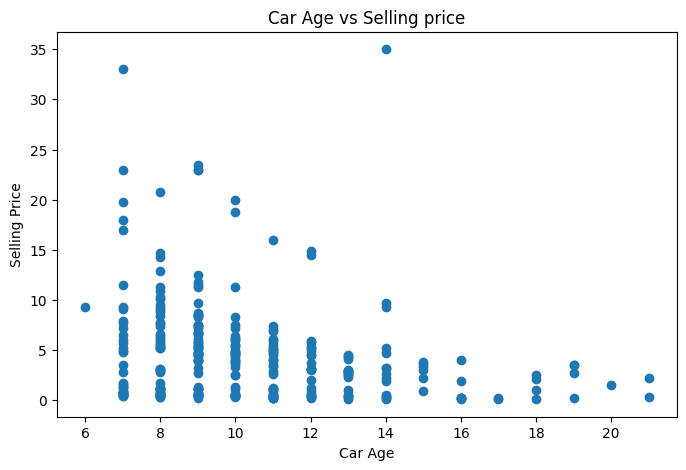

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["Car_Age"], df_clean["Selling_Price"])
plt.title("Car Age vs Selling price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

This plot shows that older cars tend to have lower prices which is pretty expected. There is still some spread in the data..meaning cars of the same age can vary in price depending on other features.

### Correlation Heatmap

This heatmap gives a quick view of how the variables relate to one another and to selling price

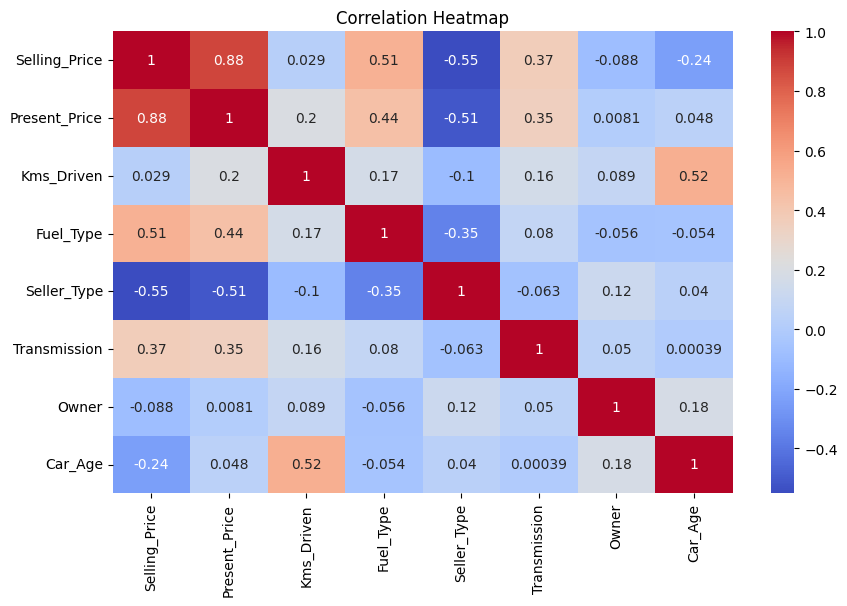

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows how strongly each feature is related to selling price. So features like car age and mileage show noticeable relationships while others may have weaker correlations.
-helps give an idea of which variables might be important for prediction

## Preparing Data for Modeling

In [17]:
X= df_clean.drop("Selling_Price", axis=1)
y= df_clean["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (240, 7)
Testing shape: (61, 7)


## Linear Regression Model

In [20]:
lr_model= LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mse= mean_squared_error(y_test, y_pred_lr)
lr_mae= mean_absolute_error(y_test, y_pred_lr)
lr_r2= r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MSE:", lr_mse)
print("MAE:", lr_mae)
print("R^2:", lr_r2)

Linear Regression Results
MSE: 3.5289272538906156
MAE: 1.2217615462332652
R^2: 0.8468053957657441


The linear regression model provides a good baseline for prediction. The R2 value shows that the model can explain a big portion of the variation in selling price which suggests that the selected features are useful predictors.

But since linear regression assumes a linear relationship between variables..it might still miss more complex patterns in the data.

## Scaling the Data

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) #fit on training data and transform
X_test_scaled = scaler.transform(X_test) #just transform test data

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (240, 7)
Scaled testing shape: (61, 7)


The scaled training and testing data both have the same # of features so that confirms that the transformation was applied.

## Neural network model (TensorFlow)

In [27]:
nn_model= keras.Sequential([
    keras.layers.Dense(16, activation="relu", input_shape=[X_train_scaled.shape[1]]),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1)
])

nn_model.compile(optimizer="adam", loss="mse")

history= nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 54.3547 - val_loss: 53.9076
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 53.4627 - val_loss: 53.1036
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 52.6708 - val_loss: 52.3383
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 52.0556 - val_loss: 51.6094
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 51.3451 - val_loss: 50.9349
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 50.6428 - val_loss: 50.3289
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 50.1031 - val_loss: 49.7205
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 49.5221 - val_loss: 49.1681
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 49.0227 - val_loss: 48.6332
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 48.4933 - val_loss: 48.1231
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 48.0411 - val_loss: 47.5935
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 47.55

## Training Loss

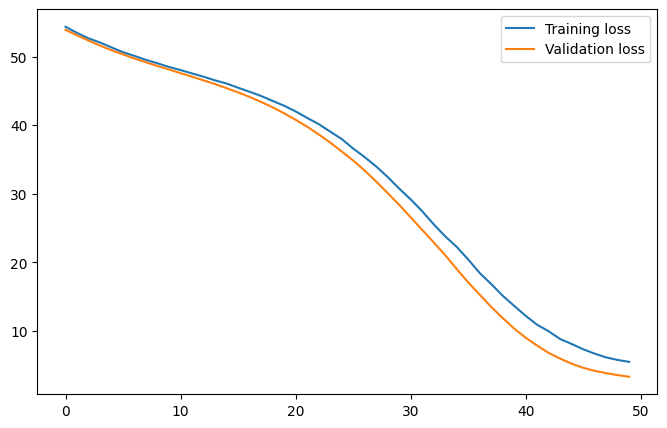

In [28]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.legend()
plt.show()

Both lines decreasing shows the model is learning. If validation loss increases it would mean overfitting

## Evaluating Neural Network

In [29]:
y_pred_nn= nn_model.predict(X_test_scaled).flatten()

nn_mse= mean_squared_error(y_test, y_pred_nn)
nn_mae= mean_absolute_error(y_test, y_pred_nn)
nn_r2= r2_score(y_test, y_pred_nn)

print("Neural Network Results")
print("MSE:", nn_mse)
print("MAE:", nn_mae)
print("R^2:", nn_r2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Neural Network Results
MSE: 4.170596331022584
MAE: 1.3272270990590582
R^2: 0.818949837051062


The neural network can capture more complex patterns compared to the linear regression

## Predicted vs Actual Prices

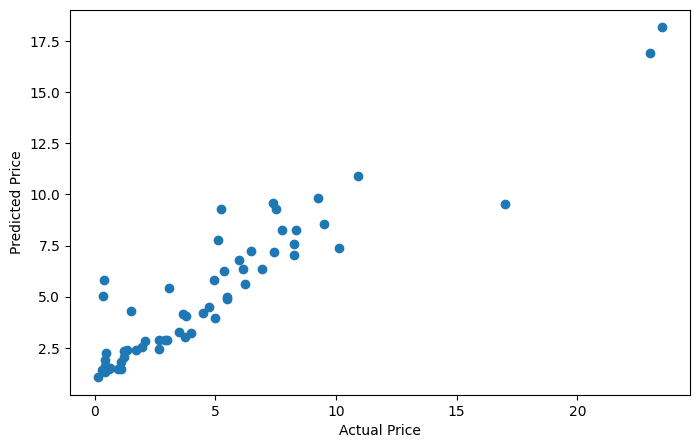

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_nn)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

Points closer to a diagonal line mean better predictions. The spread shows error in the model.

## Model Comparison

In [31]:
results= pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "MSE": [lr_mse, nn_mse],
    "MAE": [lr_mae, nn_mae],
    "R^2": [lr_r2, nn_r2]
})

display(results)

,Model,MSE,MAE,R^2
0,Linear Regression,3.528927,1.221762,0.846805
1,Neural Network,4.170596,1.327227,0.818950


Made a table because it easier to compare how both models performed

## Conclusion
This project looked at which factors affect used car prices and how well different models can predict those prices.

From the graphs...car age and mileage seemed to have the biggest impact. But as expected, older cars and cars with more miles were priced lower. The linear regression model gave a good starting point and was able to capture some of these patterns. The neural network also worked well and was able to pick up on slightly more complex relationships in the data.

Overall, both models were able to make reasonable predictions but the neural network gave a more flexible approach.